In [3]:
%load_ext autoreload
%autoreload 2

# Global libraries
import os
import torch
from torch.utils.data import DataLoader
from collections import defaultdict
from torchviz import make_dot 
from PIL import ImageFont
from torchinfo import summary
from src.constants import DEVICE

# Local libraries
from src.get_multi_model import get_classification_model
from src.get_config import get_config
from src.load_dataset import load_dataset_total

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# Install the following
#   - App:          graphviz
#   - Python Lib:   pip install graphviz
#   - Python Lib:   pip install torchviz

# Also set graphviz location to PATH
if(False):
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [4]:
# Load the configurations for the model
config = get_config('DETOXLung_config')

# Load example dataset for input and output expectations of model
dataset, metadata = load_dataset_total(config)

# Get model
model = get_classification_model(config,metadata)

src/Config_presets/Base_config.yaml
src/Config_presets/DETOXLung_config.yaml
Patient collection --> Train: 1236, Validation: 156


c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Layer (type (var_name))                            Input Shape               Output Shape              Param #                   Kernel Shape
MultiTox_Classifier (MultiTox_Classifier)          [8, 3, 180, 135, 170]     [8, 1]                    --                        --
├─DCNN_Pooling (encoder)                           [8, 3, 180, 135, 170]     [8, 32, 5, 4, 5]          --                        --
│    └─ModuleList (conv_blocks)                    --                        --                        --                        --
│    │    └─small_conv_block (conv_block0)         [8, 3, 180, 135, 170]     [8, 8, 90, 67, 85]        --                        --
│    │    │    └─conv3d_padding_same (pad)         [8, 3, 180, 135, 170]     [8, 3, 186, 141, 176]     --                        [7, 7, 7]
│    │    │    └─Conv3d (conv1)                    [8, 3, 186, 141, 176]     [8, 8, 180, 135, 170]     8,240                     [7, 7, 7]
│    │    │    └─BatchNorm3d (norm1)               [

TypeError: join() argument must be str, bytes, or os.PathLike object, not 'int'

In [16]:

def create_folder(path):
    dirPath = path
    if(os.path.dirname(path) == False):
            dirPath = os.path.dirname(path)
    if(os.path.exists(dirPath) == False):
        os.mkdir(dirPath)

config["general"]["trialNumber"] = "Trial"
path = os.path.join(config["paths"]["output"],config["hyperparam_tuning"]["ProjectName"])
path = os.path.join(path,config["general"]["trialNumber"])

create_folder(path)

In [11]:
config["general"]["trialNumber"] = "Trial"
path = os.path.join(config["paths"]["output"],config["hyperparam_tuning"]["ProjectName"])
path = os.path.join(path,config["general"]["trialNumber"])
if(os.path.exists(path) == False):
    os.mkdir(path)

In [23]:
outputs = None
train_loader = DataLoader(dataset[0], batch_size=config['training']['batch_size'], shuffle=True)
for i, batch in enumerate(train_loader):
    inputs, clinical_features, targets = batch
    # Make predictions
    outputs = model(x=inputs, features=clinical_features)
    break

In [45]:
clinical_features.shape

torch.Size([8, 18])

In [43]:
inputs.shape


torch.Size([8, 3, 180, 135, 170])

In [46]:
clinicalFeatures = config['columns']['clinical_features']
inputShapeGiven = [(8,3,180,135,170),(8,18)]
print(inputShapeGiven)
summary(model,input_size= inputShapeGiven,device="CUDA")

[(8, 3, 180, 135, 170), (8, 18)]


RuntimeError: Expected 4D (unbatched) or 5D (batched) input to conv3d, but got input of size: [2, 1, 3, 186, 141, 176]

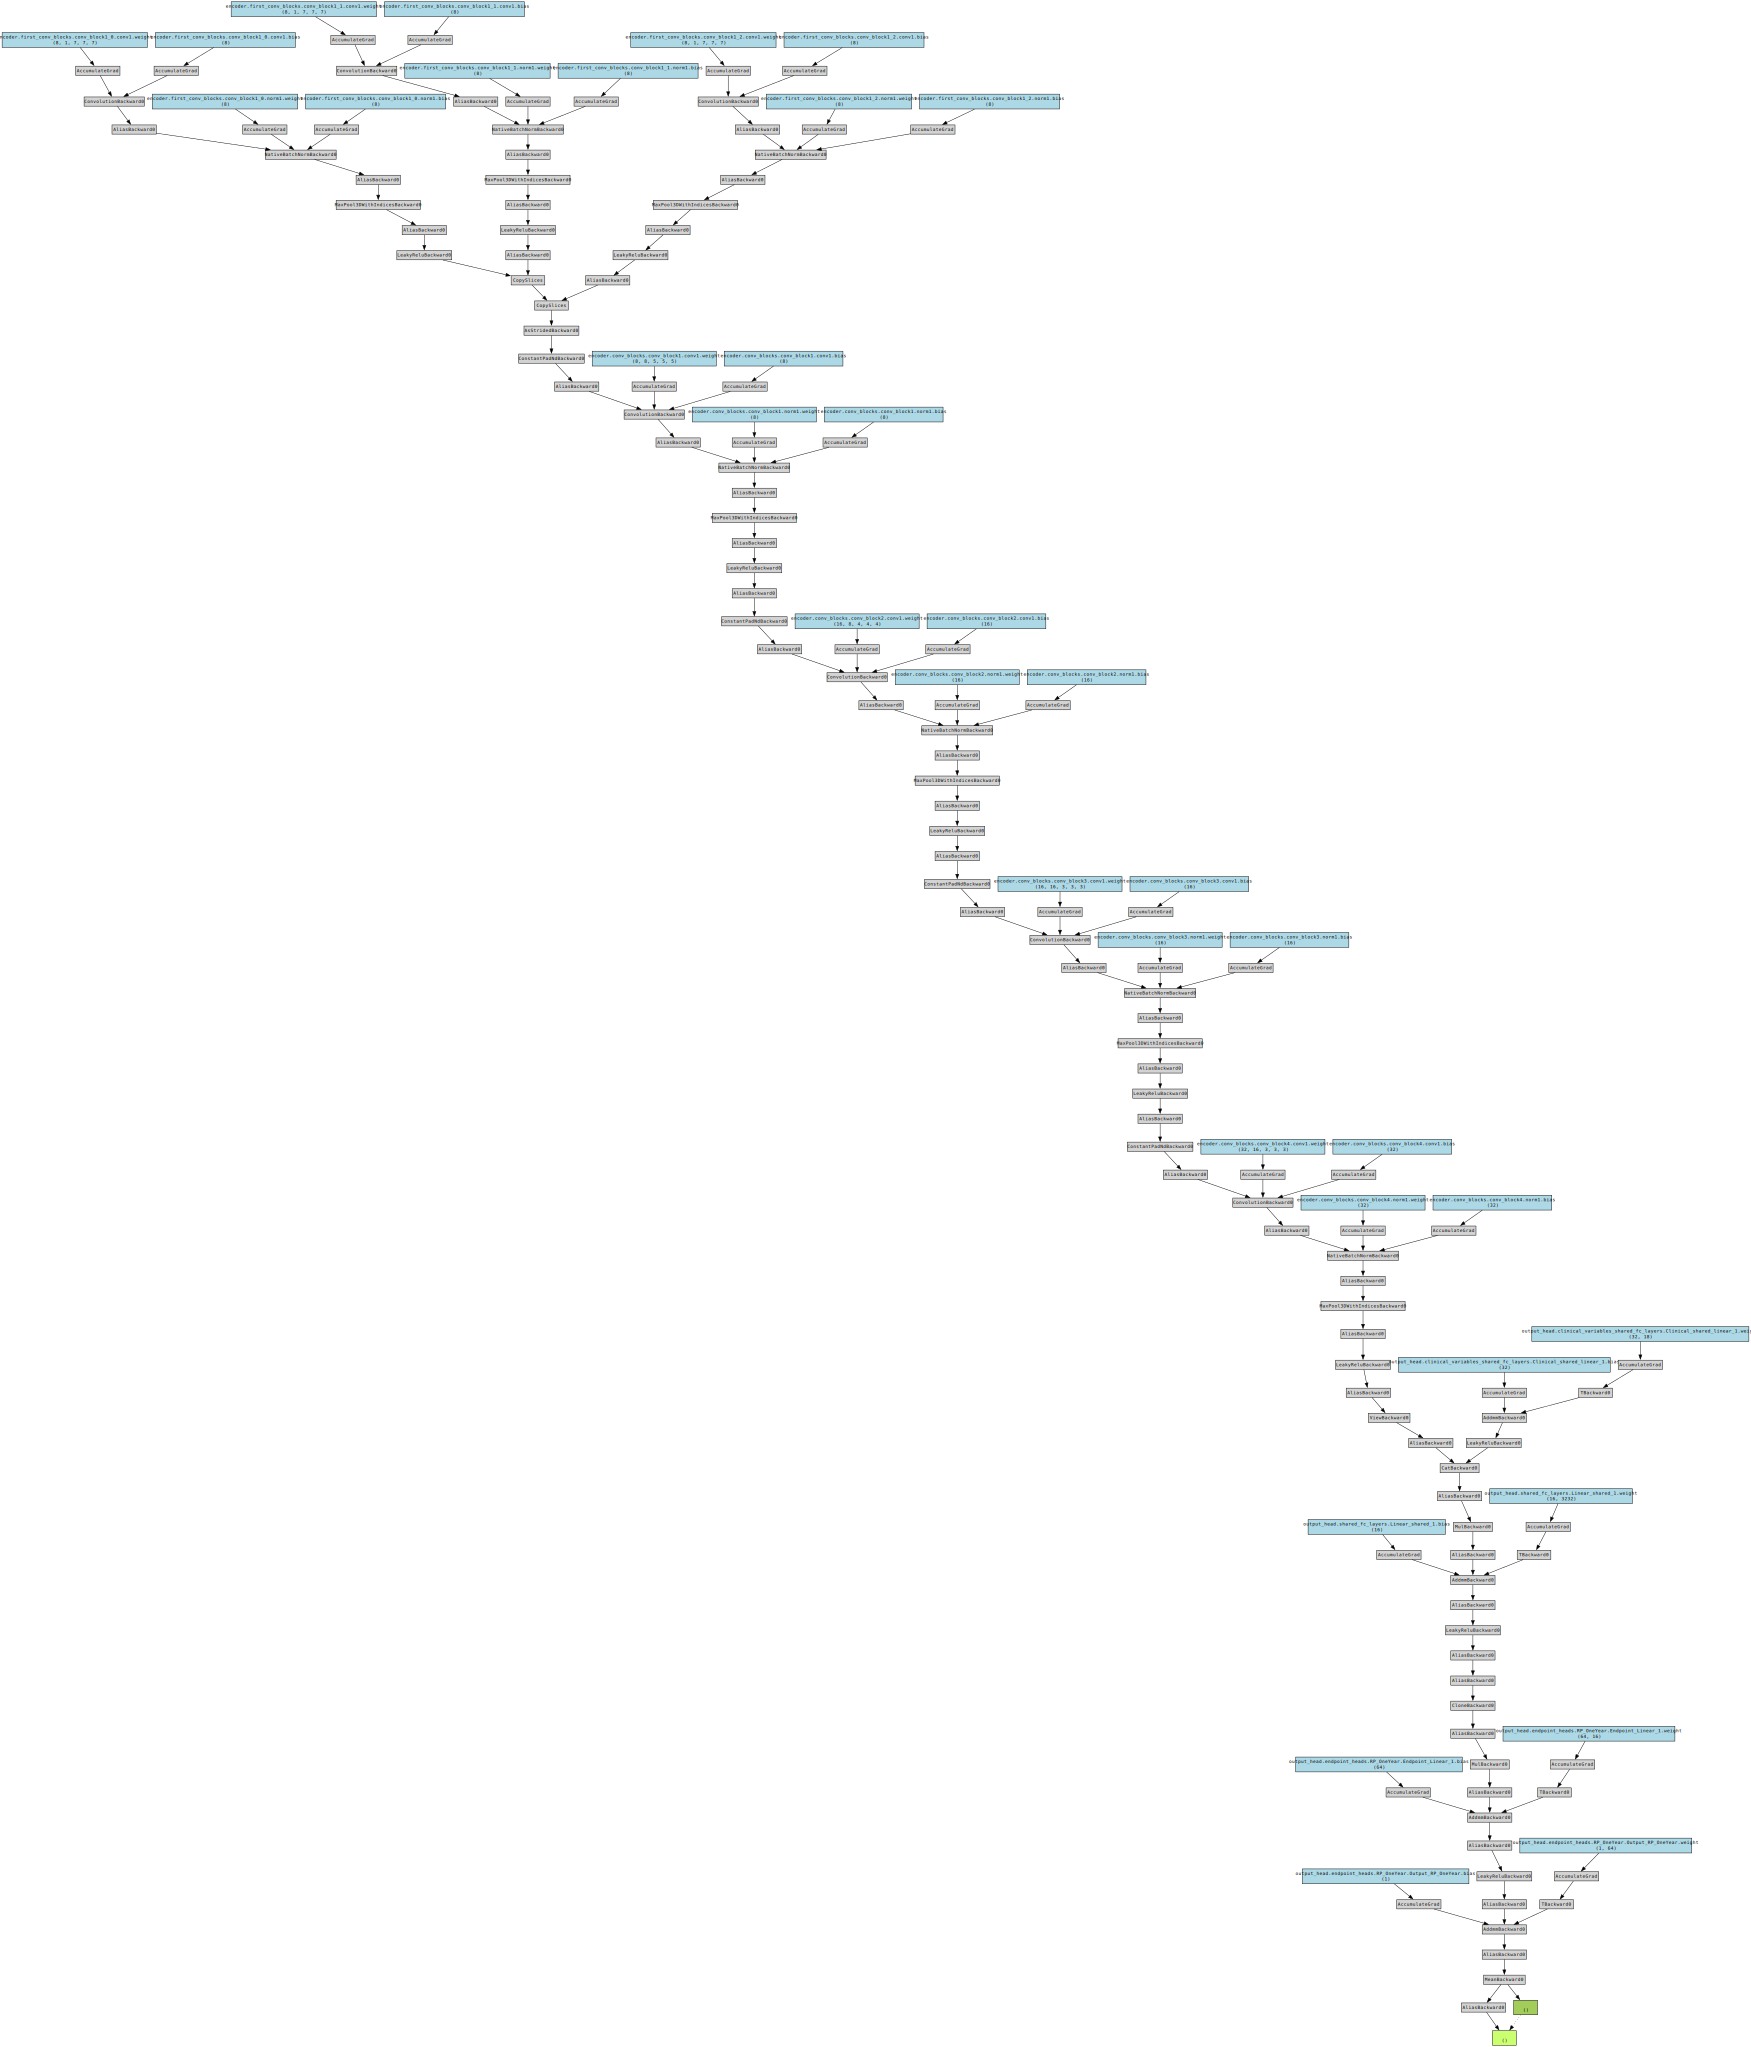

In [24]:
# Create the flowdiagram of the model ()
make_dot(outputs['RP_OneYear'].mean(),params=dict(model.named_parameters()))